<a href="https://colab.research.google.com/github/mbryan56/Intro-Machine-Learning-Projects/blob/main/Homework_3_Intro_Machine_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

=== PROCESSING PROBLEM 1: DIABETES ===
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Accuracy:  0.7013
Precision: 0.5833
Recall:    0.5185
F1 Score:  0.5490


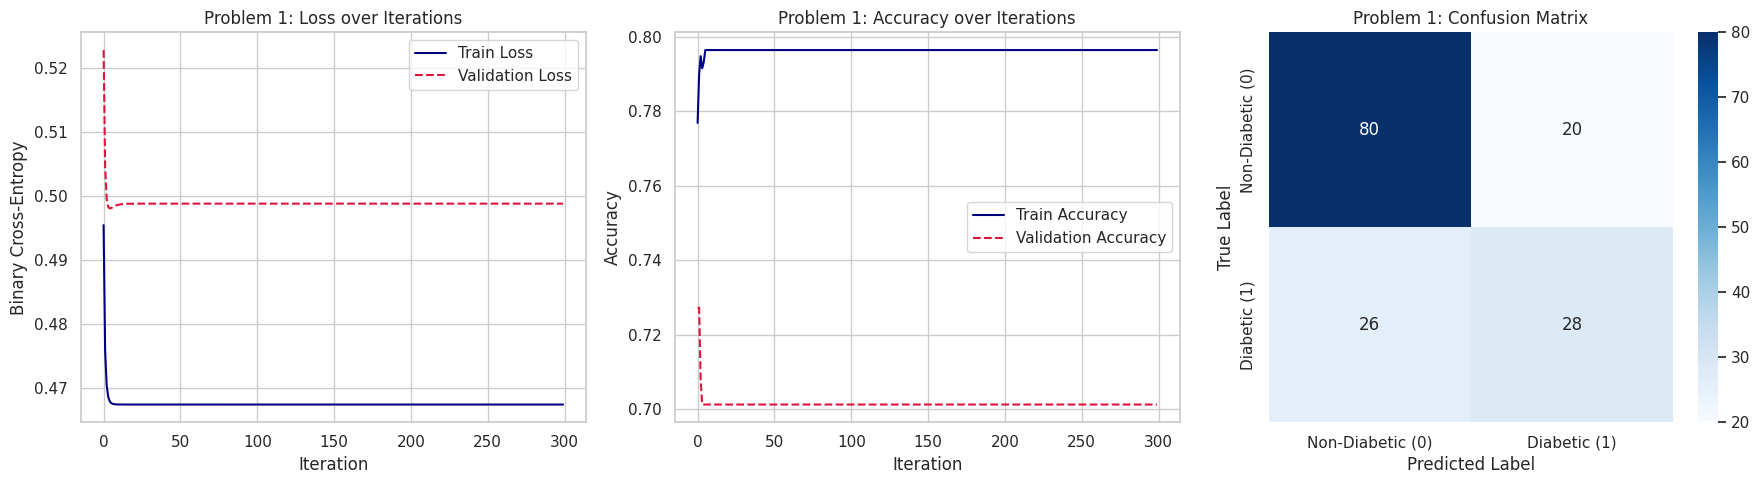

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, log_loss
)

# Set global configuration
RANDOM_STATE = 42
N_ITERATIONS = 300
LEARNING_RATE = 0.01

sns.set_theme(style="whitegrid")

print("=== PROCESSING PROBLEM 1: DIABETES ===")

# Load Data
drive.mount('/content/drive')
file_path = '/content/drive/My Drive/Intro to ML/Datasets/diabetes.csv'
df = pd.read_csv(file_path)
df.head()
X_d = df.drop('Outcome', axis=1)
y_d = df['Outcome']

# Train/Test Split (80/20 Stratified)
X_tr_d, X_te_d, y_tr_d, y_te_d = train_test_split(
    X_d, y_d, test_size=0.20, random_state=RANDOM_STATE, stratify=y_d
)

# Standardization
scaler_d = StandardScaler()
X_tr_d_scaled = scaler_d.fit_transform(X_tr_d)
X_te_d_scaled = scaler_d.transform(X_te_d)

# Model Training via Gradient Descent
clf_d = SGDClassifier(
    loss='log_loss', penalty=None, learning_rate='constant',
    eta0=LEARNING_RATE, random_state=RANDOM_STATE, warm_start=True
)

train_loss_d, test_loss_d = [], []
train_acc_d, test_acc_d = [], []
classes_d = np.unique(y_tr_d)

for iteration in range(N_ITERATIONS):
    clf_d.partial_fit(X_tr_d_scaled, y_tr_d, classes=classes_d)

    # Track Loss and Accuracy over iterations
    tr_proba = clf_d.predict_proba(X_tr_d_scaled)
    te_proba = clf_d.predict_proba(X_te_d_scaled)
    train_loss_d.append(log_loss(y_tr_d, tr_proba))
    test_loss_d.append(log_loss(y_te_d, te_proba))

    train_acc_d.append(accuracy_score(y_tr_d, clf_d.predict(X_tr_d_scaled)))
    test_acc_d.append(accuracy_score(y_te_d, clf_d.predict(X_te_d_scaled)))

# Final Evaluation Metrics
y_pred_d = clf_d.predict(X_te_d_scaled)

print(f"Accuracy:  {accuracy_score(y_te_d, y_pred_d):.4f}")
print(f"Precision: {precision_score(y_te_d, y_pred_d):.4f}")
print(f"Recall:    {recall_score(y_te_d, y_pred_d):.4f}")
print(f"F1 Score:  {f1_score(y_te_d, y_pred_d):.4f}")

# Plot Loss, Accuracy, and Confusion Matrix
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(train_loss_d, label='Train Loss', color='navy')
axes[0].plot(test_loss_d, label='Validation Loss', color='crimson', linestyle='--')
axes[0].set_title('Problem 1: Loss over Iterations')
axes[0].set_xlabel('Iteration')
axes[0].set_ylabel('Binary Cross-Entropy')
axes[0].legend()

axes[1].plot(train_acc_d, label='Train Accuracy', color='navy')
axes[1].plot(test_acc_d, label='Validation Accuracy', color='crimson', linestyle='--')
axes[1].set_title('Problem 1: Accuracy over Iterations')
axes[1].set_xlabel('Iteration')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

cm_d = confusion_matrix(y_te_d, y_pred_d)
sns.heatmap(cm_d, annot=True, fmt='d', cmap='Blues', ax=axes[2],
            xticklabels=['Non-Diabetic (0)', 'Diabetic (1)'],
            yticklabels=['Non-Diabetic (0)', 'Diabetic (1)'])
axes[2].set_title('Problem 1: Confusion Matrix')
axes[2].set_xlabel('Predicted Label')
axes[2].set_ylabel('True Label')

plt.tight_layout()
plt.show()

=== PROCESSING PROBLEM 2: CANCER ===

--- Problem 2a (Unregularized) ---
Accuracy:  0.9737
Precision: 0.9756
Recall:    0.9524
F1 Score:  0.9639

--- Problem 2b (L2 Regularized) ---
Accuracy:  0.9825
Precision: 1.0000
Recall:    0.9524
F1 Score:  0.9756


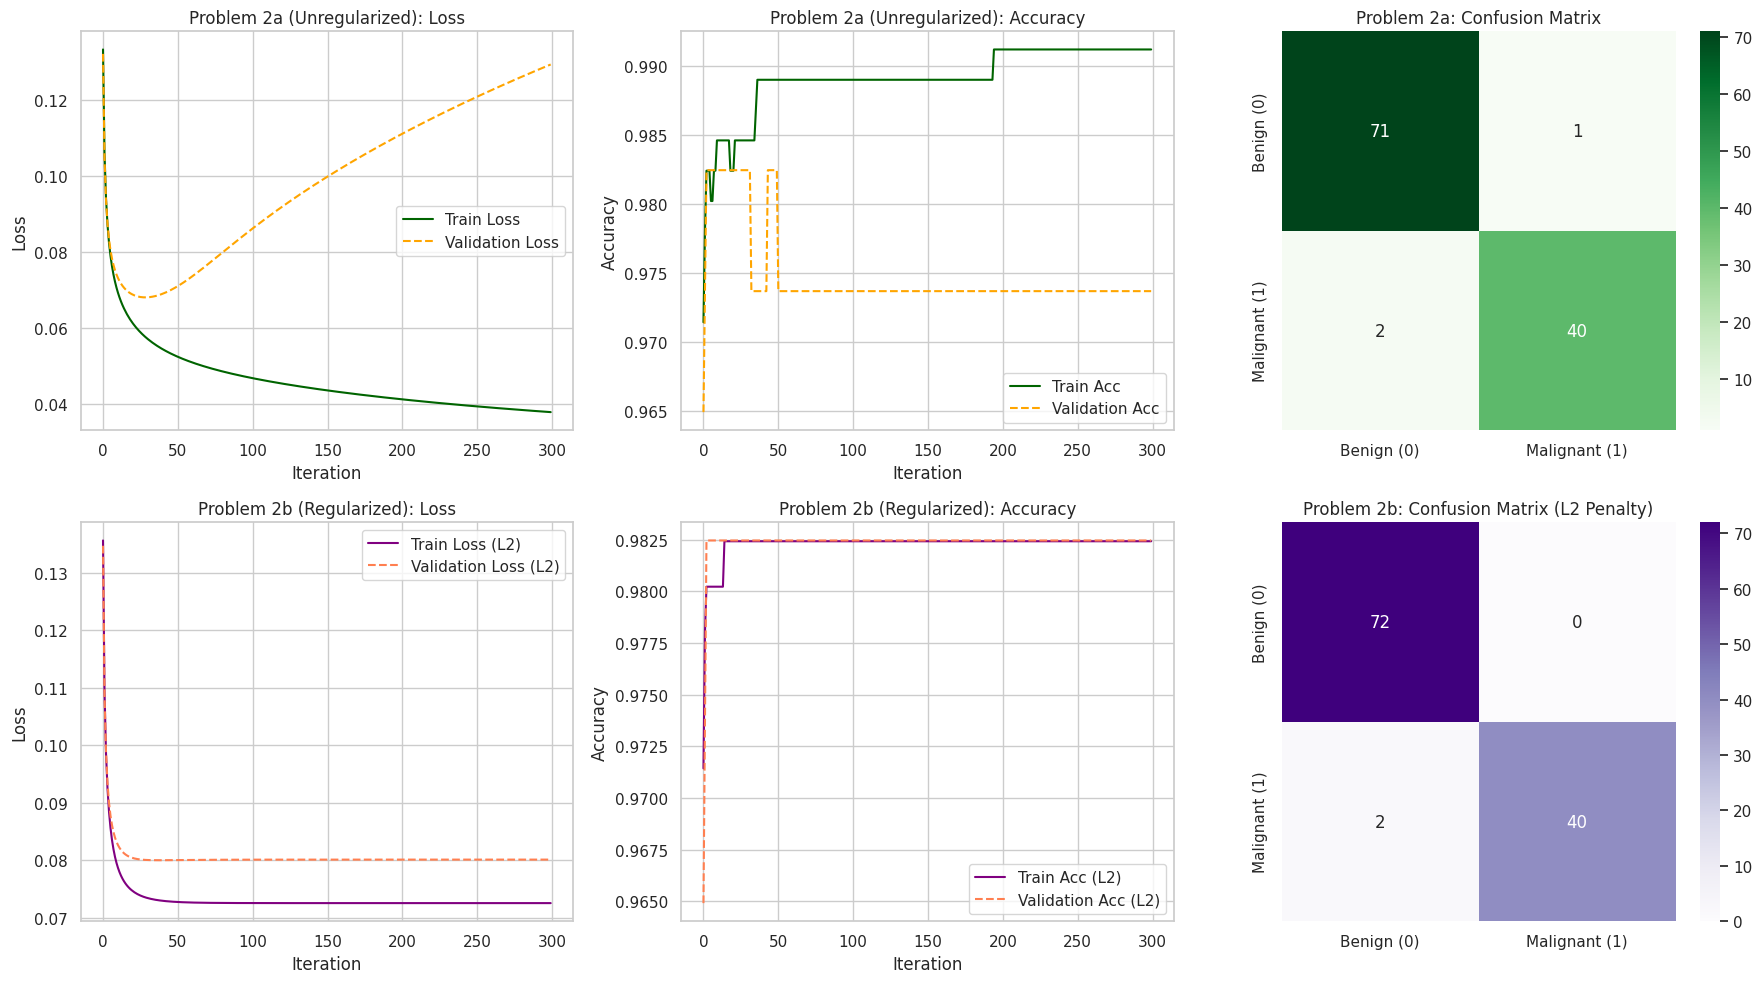

In [10]:
print("=== PROCESSING PROBLEM 2: CANCER ===")

# Load Data & Clean
file_path = '/content/drive/My Drive/Intro to ML/Datasets/Cancer.csv'
df = pd.read_csv(file_path)
df.head()
if 'Unnamed: 32' in df.columns:
    df = df.drop('Unnamed: 32', axis=1)
if 'id' in df.columns:
    df = df.drop('id', axis=1)

# Map target: M (Malignant) -> 1, B (Benign) -> 0
df['diagnosis'] = df['diagnosis'].map({'M': 1, 'B': 0})

X_c = df.drop('diagnosis', axis=1)
y_c = df['diagnosis']

# Train/Test Split (80/20 Stratified)
X_tr_c, X_te_c, y_tr_c, y_te_c = train_test_split(
    X_c, y_c, test_size=0.20, random_state=RANDOM_STATE, stratify=y_c
)

# Standardization
scaler_c = StandardScaler()
X_tr_c_scaled = scaler_c.fit_transform(X_tr_c)
X_te_c_scaled = scaler_c.transform(X_te_c)

classes_c = np.unique(y_tr_c)

# --- PART A: UNREGULARIZED LOGISTIC REGRESSION ---
clf_c_unreg = SGDClassifier(
    loss='log_loss', penalty=None, learning_rate='constant',
    eta0=LEARNING_RATE, random_state=RANDOM_STATE, warm_start=True
)

train_loss_c1, test_loss_c1 = [], []
train_acc_c1, test_acc_c1 = [], []

for iteration in range(N_ITERATIONS):
    clf_c_unreg.partial_fit(X_tr_c_scaled, y_tr_c, classes=classes_c)

    tr_proba = clf_c_unreg.predict_proba(X_tr_c_scaled)
    te_proba = clf_c_unreg.predict_proba(X_te_c_scaled)
    train_loss_c1.append(log_loss(y_tr_c, tr_proba))
    test_loss_c1.append(log_loss(y_te_c, te_proba))

    train_acc_c1.append(accuracy_score(y_tr_c, clf_c_unreg.predict(X_tr_c_scaled)))
    test_acc_c1.append(accuracy_score(y_te_c, clf_c_unreg.predict(X_te_c_scaled)))

y_pred_c1 = clf_c_unreg.predict(X_te_c_scaled)

print("\n--- Problem 2a (Unregularized) ---")
print(f"Accuracy:  {accuracy_score(y_te_c, y_pred_c1):.4f}")
print(f"Precision: {precision_score(y_te_c, y_pred_c1):.4f}")
print(f"Recall:    {recall_score(y_te_c, y_pred_c1):.4f}")
print(f"F1 Score:  {f1_score(y_te_c, y_pred_c1):.4f}")

# --- PART B: REGULARIZED LOGISTIC REGRESSION (L2 WEIGHT PENALTY) ---
clf_c_reg = SGDClassifier(
    loss='log_loss', penalty='l2', alpha=0.01, learning_rate='constant',
    eta0=LEARNING_RATE, random_state=RANDOM_STATE, warm_start=True
)

train_loss_c2, test_loss_c2 = [], []
train_acc_c2, test_acc_c2 = [], []

for iteration in range(N_ITERATIONS):
    clf_c_reg.partial_fit(X_tr_c_scaled, y_tr_c, classes=classes_c)

    tr_proba = clf_c_reg.predict_proba(X_tr_c_scaled)
    te_proba = clf_c_reg.predict_proba(X_te_c_scaled)
    train_loss_c2.append(log_loss(y_tr_c, tr_proba))
    test_loss_c2.append(log_loss(y_te_c, te_proba))

    train_acc_c2.append(accuracy_score(y_tr_c, clf_c_reg.predict(X_tr_c_scaled)))
    test_acc_c2.append(accuracy_score(y_te_c, clf_c_reg.predict(X_te_c_scaled)))

y_pred_c2 = clf_c_reg.predict(X_te_c_scaled)

print("\n--- Problem 2b (L2 Regularized) ---")
print(f"Accuracy:  {accuracy_score(y_te_c, y_pred_c2):.4f}")
print(f"Precision: {precision_score(y_te_c, y_pred_c2):.4f}")
print(f"Recall:    {recall_score(y_te_c, y_pred_c2):.4f}")
print(f"F1 Score:  {f1_score(y_te_c, y_pred_c2):.4f}")

# --- PLOTTING PROBLEM 2 COMPARISONS ---
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 2a Curves
axes[0, 0].plot(train_loss_c1, label='Train Loss', color='darkgreen')
axes[0, 0].plot(test_loss_c1, label='Validation Loss', color='orange', linestyle='--')
axes[0, 0].set_title('Problem 2a (Unregularized): Loss')
axes[0, 0].set_xlabel('Iteration')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].legend()

axes[0, 1].plot(train_acc_c1, label='Train Acc', color='darkgreen')
axes[0, 1].plot(test_acc_c1, label='Validation Acc', color='orange', linestyle='--')
axes[0, 1].set_title('Problem 2a (Unregularized): Accuracy')
axes[0, 1].set_xlabel('Iteration')
axes[0, 1].set_ylabel('Accuracy')
axes[0, 1].legend()

sns.heatmap(confusion_matrix(y_te_c, y_pred_c1), annot=True, fmt='d', cmap='Greens', ax=axes[0, 2],
            xticklabels=['Benign (0)', 'Malignant (1)'], yticklabels=['Benign (0)', 'Malignant (1)'])
axes[0, 2].set_title('Problem 2a: Confusion Matrix')

# 2b Curves
axes[1, 0].plot(train_loss_c2, label='Train Loss (L2)', color='purple')
axes[1, 0].plot(test_loss_c2, label='Validation Loss (L2)', color='coral', linestyle='--')
axes[1, 0].set_title('Problem 2b (Regularized): Loss')
axes[1, 0].set_xlabel('Iteration')
axes[1, 0].set_ylabel('Loss')
axes[1, 0].legend()

axes[1, 1].plot(train_acc_c2, label='Train Acc (L2)', color='purple')
axes[1, 1].plot(test_acc_c2, label='Validation Acc (L2)', color='coral', linestyle='--')
axes[1, 1].set_title('Problem 2b (Regularized): Accuracy')
axes[1, 1].set_xlabel('Iteration')
axes[1, 1].set_ylabel('Accuracy')
axes[1, 1].legend()

sns.heatmap(confusion_matrix(y_te_c, y_pred_c2), annot=True, fmt='d', cmap='Purples', ax=axes[1, 2],
            xticklabels=['Benign (0)', 'Malignant (1)'], yticklabels=['Benign (0)', 'Malignant (1)'])
axes[1, 2].set_title('Problem 2b: Confusion Matrix (L2 Penalty)')

plt.tight_layout()
plt.show()